<a href="https://colab.research.google.com/github/krish52-git/swiggy-data-analysis/blob/main/swiggy_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

swiggy data analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import the data

In [6]:
df = pd.read_excel('/content/swiggy_data (2).xlsx')

In [10]:
df.head(10)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0
5,Karnataka,Bengaluru,2025-07-08,Srinidhi Sagar Deluxe,Kengeri,Recommended,Srinidhi Sagar Special,312.0,4.0,0
6,Karnataka,Bengaluru,2025-01-21,Srinidhi Sagar Deluxe,Kengeri,Recommended,Garlic Naan,98.0,4.0,34
7,Karnataka,Bengaluru,2025-04-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Pista,137.0,4.0,0
8,Karnataka,Bengaluru,2025-05-02,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Panneer Butter Masala,241.0,4.4,29
9,Karnataka,Bengaluru,2025-07-30,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Dal Tadka,195.0,4.9,51


In [11]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [15]:
print('number of rows:',df.shape[0])

number of rows: 197430


In [16]:
print('number of columns:',df.shape[1])

number of columns: 10


data types:

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [19]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


kpi's

In [26]:
##total sales

print("total_sales:", df['Price (INR)'].sum())

total_sales: 53012505.77000001


In [28]:
##average ratings:
print("average_rating:",df['Rating'].mean())

average_rating: 4.341581826470141


In [29]:
##average order value

print("average_order_value:", df['Price (INR)'].mean())

average_order_value: 268.51291987033386


In [30]:
##rating count
print("Rating_Count:", df['Rating Count'].sum())

Rating_Count: 5591574


In [32]:
##total orders
total_orders=df['Order Date'].count()
print("total_orders:", total_orders)

total_orders: 197430


In [54]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Price (INR)'].sum()

In [50]:
display(monthly_sales)

,Rating
Order Date,
2025-01,4.344295
2025-02,4.337311
2025-03,4.346013
2025-04,4.338462
2025-05,4.340838
2025-06,4.340718
2025-07,4.340882
2025-08,4.343819


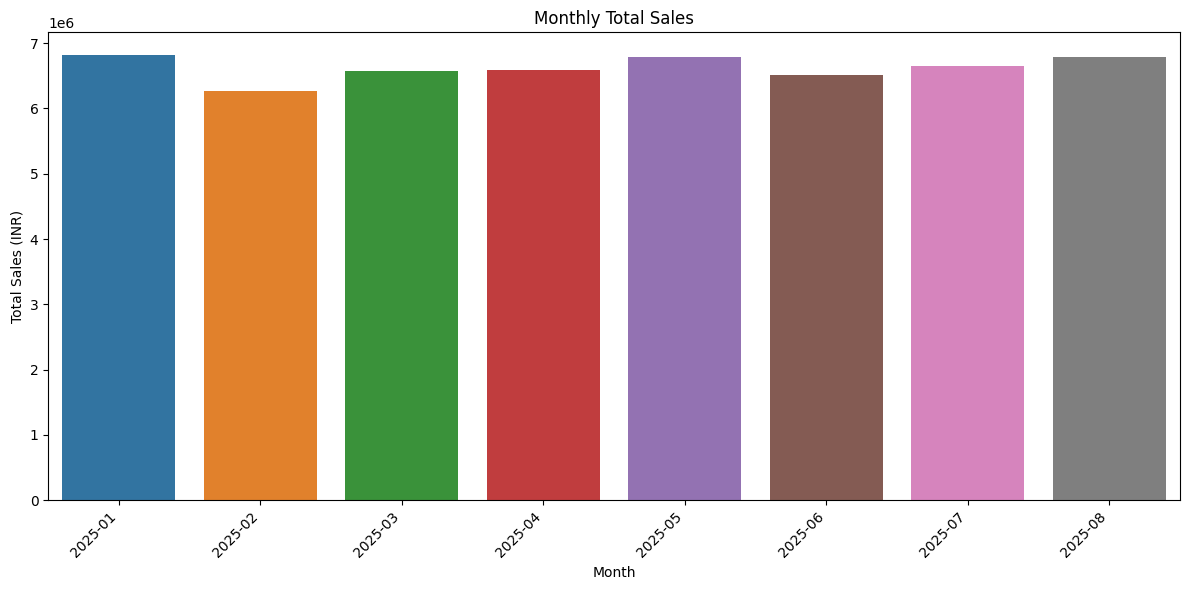

In [60]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Total Sales (INR)', data=monthly_sales_df, hue='Month', legend=False)
plt.xlabel('Month')
plt.ylabel('Total Sales (INR)')
plt.title('Monthly Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

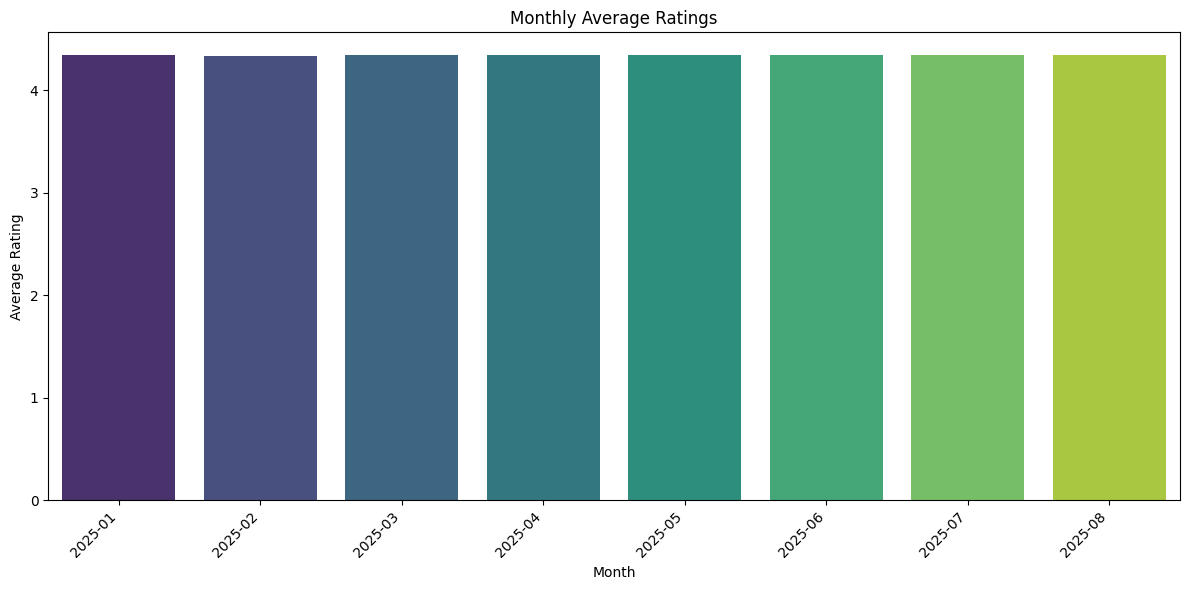

In [59]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Average Rating', data=monthly_ratings_df, hue='Month', legend=False, palette='viridis')
plt.xlabel('Month')
plt.ylabel('Average Rating')
plt.title('Monthly Average Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [63]:
category_sales = df.groupby('Veg/Non-Veg')['Price (INR)'].sum().reset_index()
category_sales.columns = ['Category', 'Total Sales (INR)']
display(category_sales)

,Category,Total Sales (INR)
0,Non-Veg,20916122.64
1,Veg,32096383.13


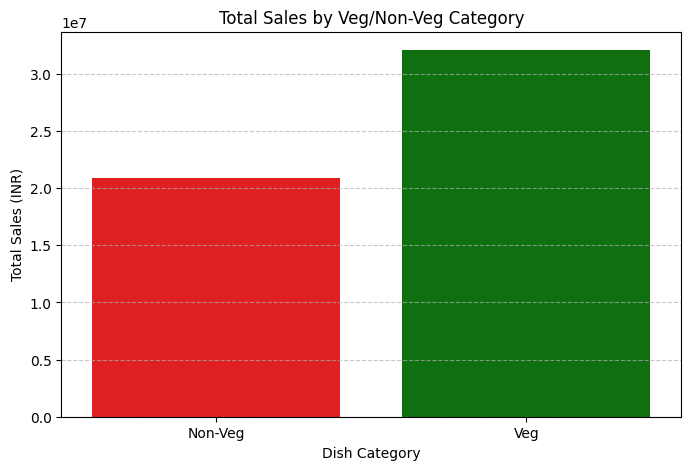

In [65]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Total Sales (INR)', data=category_sales, hue='Category', palette={'Veg': 'green', 'Non-Veg': 'red'}, legend=False)
plt.title('Total Sales by Veg/Non-Veg Category')
plt.xlabel('Dish Category')
plt.ylabel('Total Sales (INR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [67]:
top_10_restaurants = restaurant_sales.sort_values(by='Total Sales (INR)', ascending=False).head(10)
print("Top 10 restaurants by total sales created:")
display(top_10_restaurants)

Top 10 restaurants by total sales created:


,Restaurant Name,Total Sales (INR)
428,KFC,4246951.70
524,McDonald's,3343094.58
643,Pizza Hut,2133265.69
138,Burger King,1900817.09
251,Domino's Pizza,1834022.32
603,Olio - The Wood Fired Pizzeria,1236369.00
494,LunchBox - Meals and Thalis,1101141.00
84,Baskin Robbins - Ice Cream Desserts,860591.94
279,"Faasos - Wraps, Rolls & Shawarma",780215.00
891,The Good Bowl,673343.00


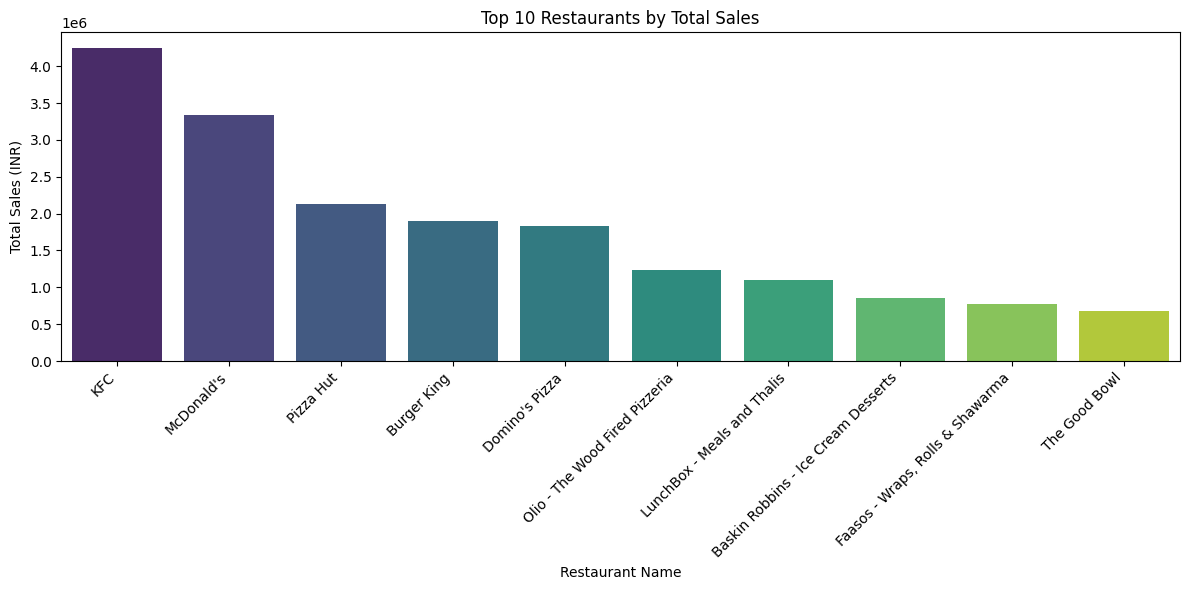

In [69]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Restaurant Name', y='Total Sales (INR)', data=top_10_restaurants, hue='Restaurant Name', legend=False, palette='viridis')
plt.xlabel('Restaurant Name')
plt.ylabel('Total Sales (INR)')
plt.title('Top 10 Restaurants by Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [70]:
state_revenue = df.groupby('State')['Price (INR)'].sum().reset_index()
state_revenue.columns = ['State', 'Total Sales (INR)']
display(state_revenue)

,State,Total Sales (INR)
0,Assam,1259012.24
1,Bihar,1231696.87
2,Chhattisgarh,1226832.20
3,Delhi,2829180.60
4,Goa,1539479.41
5,Gujarat,2817836.02
6,Haryana,1438455.54
7,Himachal Pradesh,1382689.18
8,Jammu and Kashmir,1322513.82
9,Jharkhand,1197037.32


In [76]:
fig = px.bar(
    state_revenue.sort_values("Total Sales (INR)", ascending=False),
    x='Total Sales (INR)',
    y="State",
    orientation='h',
    title='Revenue by State'
)
fig.update_layout(height=600, yaxis={'autorange': 'reversed'})
fig.show()